# COMPLETE CASE ANALYSIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../../EDA/data/data_science_job.csv")
df.head()


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.sample()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
3920,17156,city_115,0.789,Male,Has relevent experience,no_enrollment,Graduate,STEM,9.0,10000+,Pvt Ltd,2.0,0.0


In [7]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [8]:
df.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [10]:
cols = [var for var in df.columns if df[var].isnull().mean() > 0 and df[var].isnull().mean() < 0.05]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [12]:
df[cols].sample(10)

,city_development_index,enrolled_university,education_level,experience,training_hours
2411,0.866,no_enrollment,Graduate,20.0,47.0
13454,0.743,no_enrollment,Masters,9.0,24.0
9594,0.698,no_enrollment,Masters,20.0,30.0
6884,0.920,no_enrollment,Graduate,15.0,51.0
4055,NaN,no_enrollment,Graduate,2.0,56.0
17978,0.939,no_enrollment,Masters,9.0,94.0
13480,0.920,no_enrollment,Graduate,8.0,50.0
3214,0.698,Part time course,Graduate,4.0,46.0
2071,0.897,no_enrollment,Masters,2.0,45.0
18696,0.920,no_enrollment,Phd,12.0,51.0


In [13]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [ ]:
new_df = df[cols].dropna()

In [16]:
new_df.shape, df.shape

((17182, 5), (19158, 13))

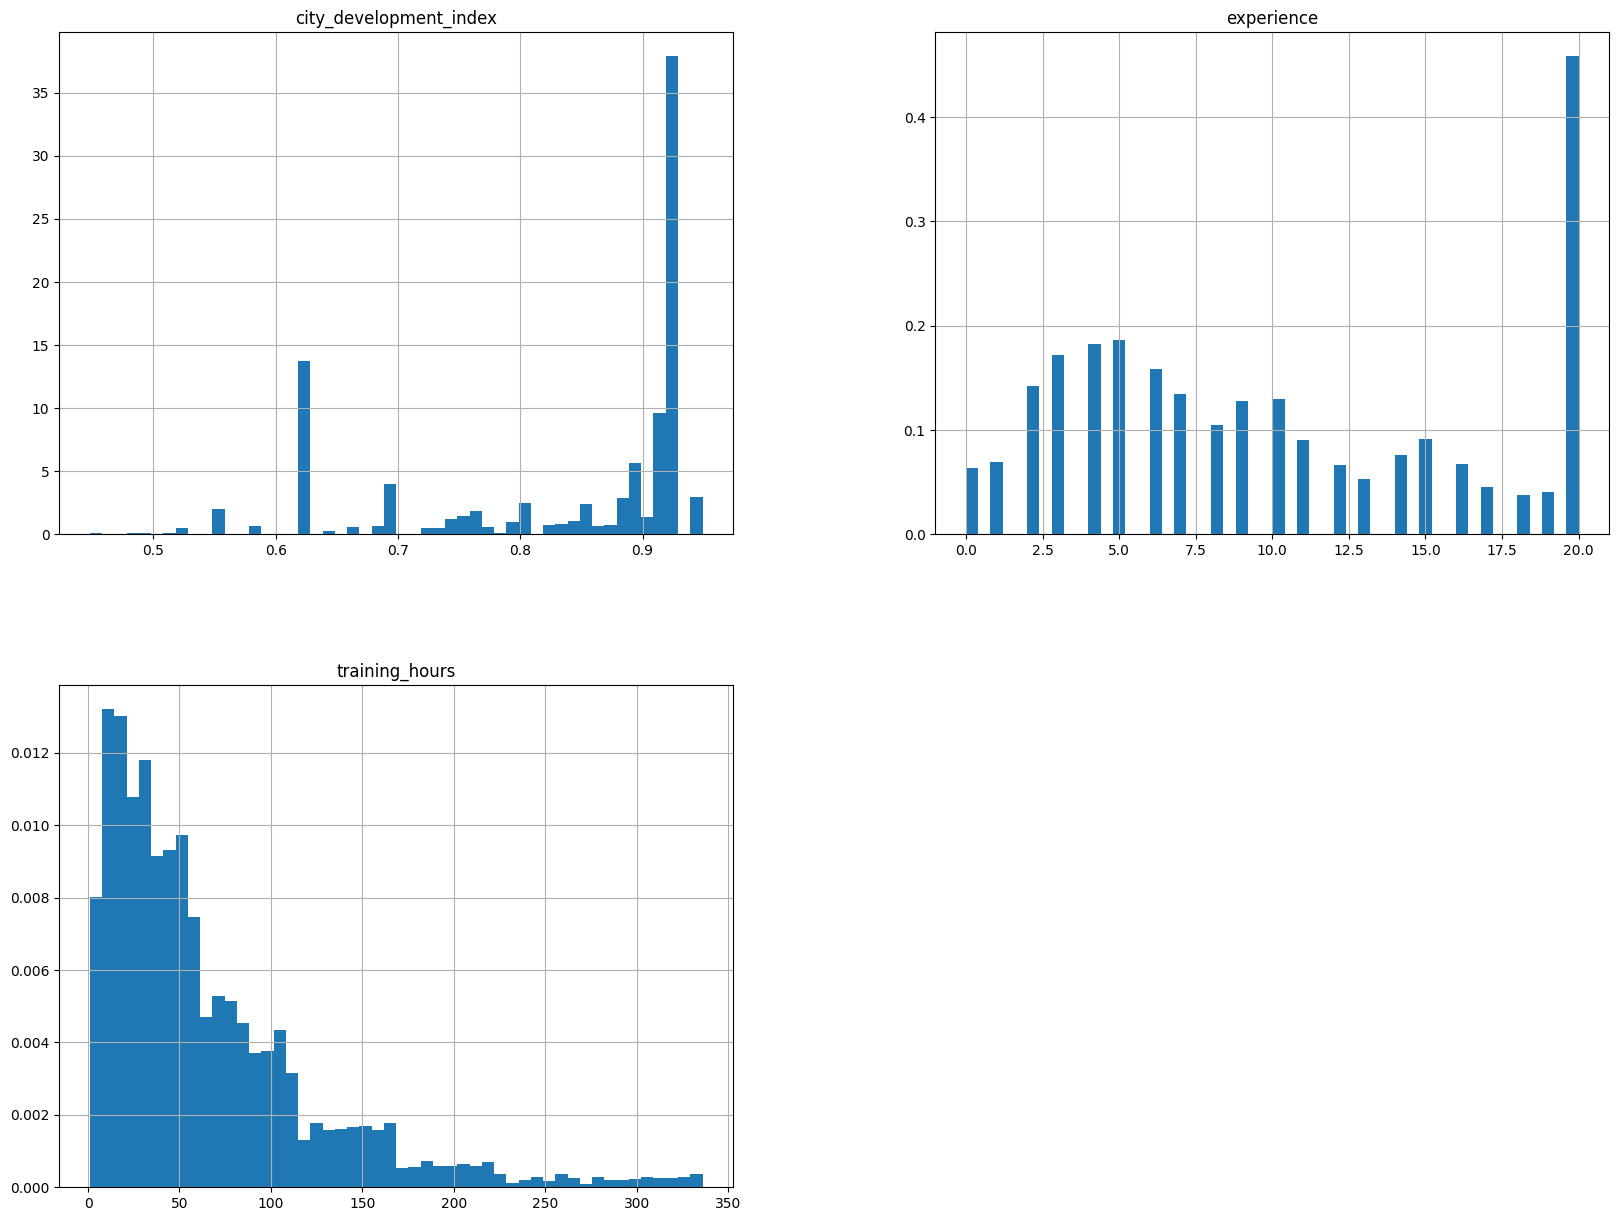

In [17]:
new_df.hist(bins=50, figsize=(20, 15), density=True)
plt.show()

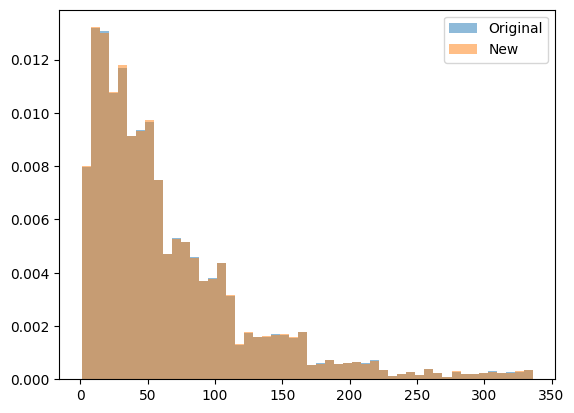

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.hist(df['training_hours'], bins=50, density=True, alpha=0.5, label='Original')

plt.hist(new_df['training_hours'], bins=50, density=True, alpha=0.5, label='New')
plt.legend()
plt.show()

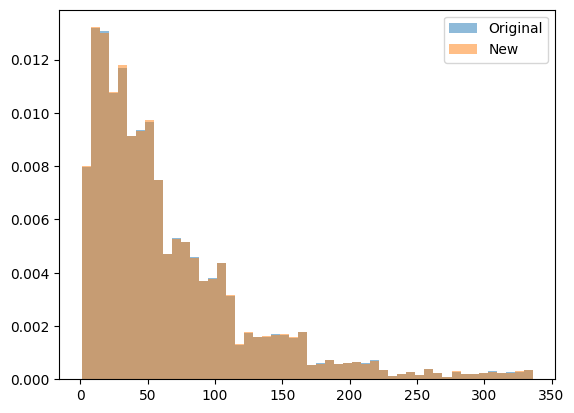

In [30]:
fig= plt.figure()
ax = fig.add_subplot(111)
plt.hist(df['training_hours'], bins=50, density=True, alpha=0.5, label='Original')
plt.hist(new_df['training_hours'], bins=50, density=True, alpha=0.5, label='New')
plt.legend()
plt.show()

<Axes: ylabel='Density'>

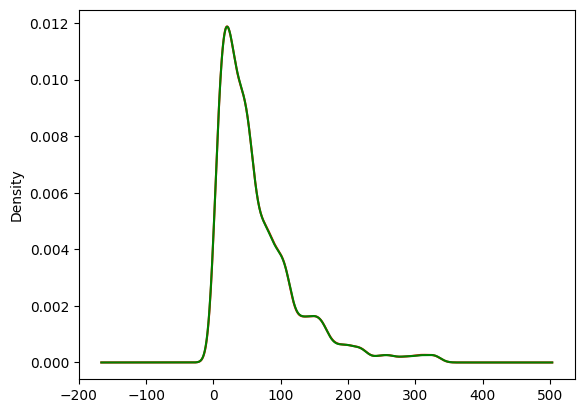

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

<Axes: >

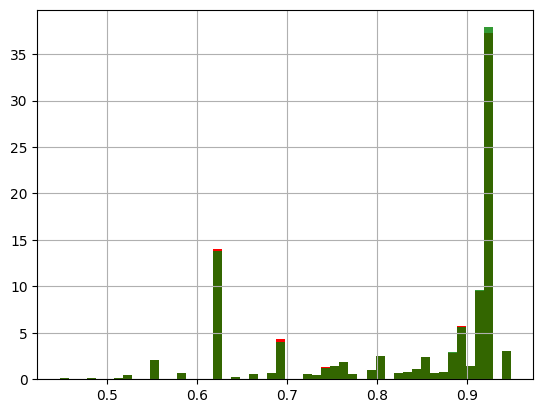

In [32]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['city_development_index'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

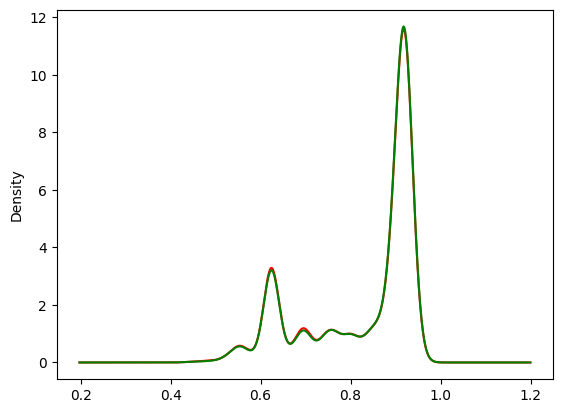

In [33]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['city_development_index'].plot.density(color='red')

# data after cca
new_df['city_development_index'].plot.density(color='green')

<Axes: >

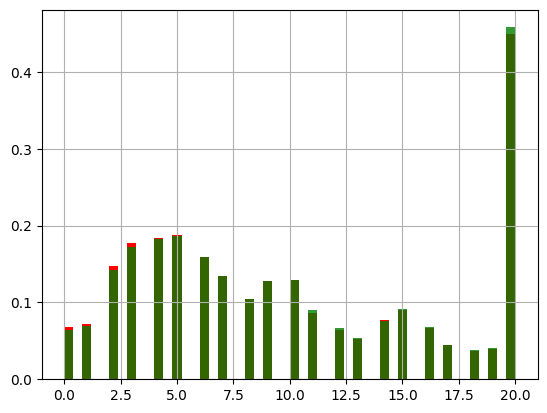

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

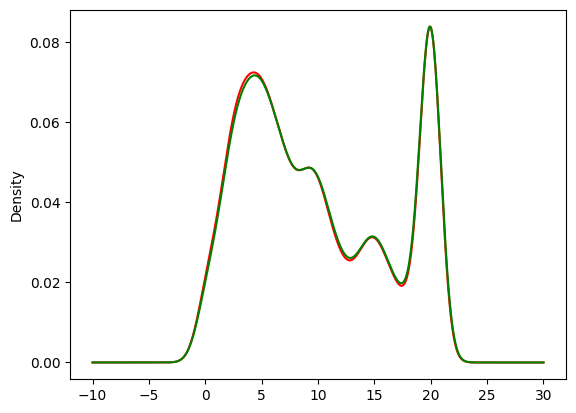

In [35]:

fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].plot.density(color='red')

# data after cca
new_df['experience'].plot.density(color='green')

In [44]:
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    new_df['enrolled_university'].value_counts() / len(new_df)
],axis=1)

In [45]:
temp.columns = ['Original', 'New']
temp

,Original,New
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [43]:
temp = pd.concat([
            # percentage of observations per category, original data
            df['education_level'].value_counts() / len(df),

            # percentage of observations per category, cca data
            new_df['education_level'].value_counts() / len(new_df)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
